<table>
    <tr>
        <td><img src='https://coastalrisk.live/wp-content/uploads/2018/05/cera_50x50.png' alt='Image' width='50' height=50'></td>
        <td><h1 align="left"><font color='green'> NetCDF Quality Check PNG File</font></h1></td>
    </tr>
</table>


Input data: C:/CERA/temp/maxele.63.nc

## 1 - Importing Python modules

In [1]:
# importing libraries
import sys
import netCDF4
import numpy
import matplotlib.pyplot as plt
import matplotlib.tri as tri
#matplotlib.use('Agg') # only enable for print only
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
# Suppress specific Cartopy user warnings
warnings.filterwarnings("ignore", category=UserWarning, module="cartopy")

## 2 - Reading input file

In [ ]:
# define the data file
file = "maxele.63.nc"
vars = netCDF4.Dataset(file).variables

# Get variable names for x, y depending on grid
if 'x' in vars:
    var_x = 'x'
    var_y = 'y'
    element = 'element'
else:
    var_x = 'lon'
    var_y = 'lat'
    element = 'ele'

# Read x, y, and elements from the grid file
x = vars[var_x][:]
y = vars[var_y][:]

elems = vars['element'][:]-1  # Move to 0-indexing by subtracting 1, elements indexing starts with '1' in netcdf file

if x is None or y is None or elems is None:
    print("*** ERROR *** No 'x (lon)', 'y (lat)', or 'element (ele)' data array given in file '%s'" % file)
    sys.exit(-1)

data = vars["zeta_max"][:]

if data is None:
    print("*** ERROR *** No '%s' data array given in file '%s'" % ("zeta_max", file))
    sys.exit(-1)

## 3 - Plotting PNG file

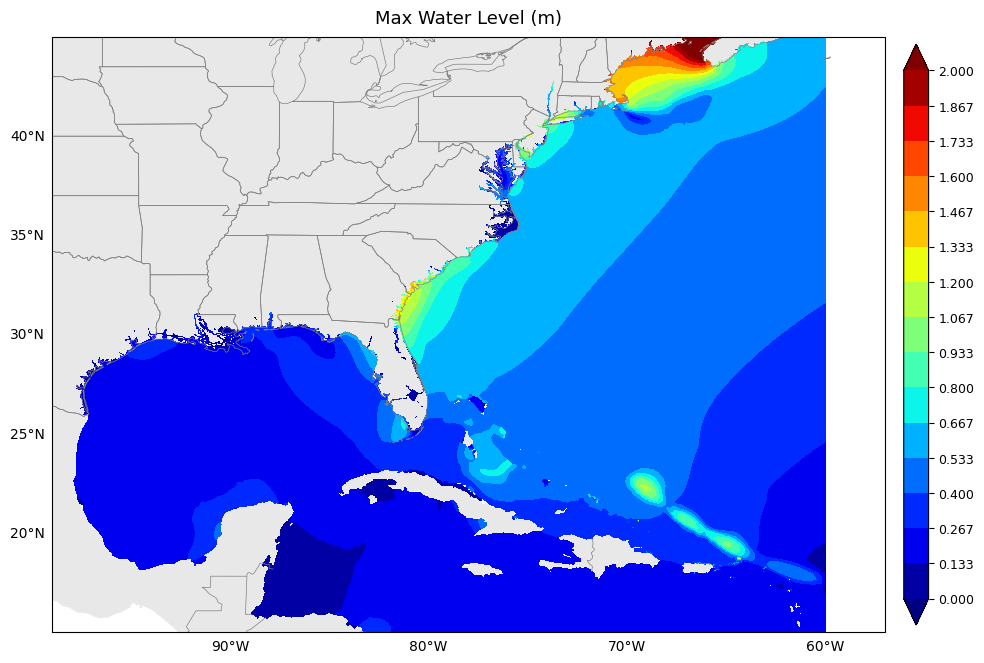

In [ ]:
# create initial plt figure, add title and background map elements
fig = plt.figure(figsize=(12.44,7)) # default in inches: 6.4, 4.8 (4:3)
ax = plt.axes([0, 0, 1, 0.85], projection=ccrs.PlateCarree()) # create subplot for the map with space for cbar (bottom,left,top,right position within 0-1 of the entire fig), set projection for cartopy

ax.set_title("Max Water Level (m)", fontsize=13, pad=10)

# add coastlines and borders
#ax.coastlines(resolution='10m', linewidth=0.5, color='darkgray')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color='gray')
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='white', alpha=1)

# Matplotlib: triangulation
triang = tri.Triangulation(x, y, triangles=elems) # with 'elem' from grid
# check if data array is masked
if data.mask.any():
    # -99999 entries in 'data' array are usually masked, mask all corresponding triangles
    point_mask_indices = numpy.where(data.mask)
    tri_mask = numpy.any(numpy.in1d(elems, point_mask_indices).reshape(-1, 3), axis=1)
    triang.set_mask(tri_mask)

# set map parameters
max_value = 2 # 0-2m water height
intervals = 16 # number of colors

levels = numpy.linspace(0, max_value, num=intervals)

# Matplotlib: create data color plot
map = plt.tricontourf(triang, data, levels=levels, cmap=plt.cm.jet, extend='both')

# add colorbar as separte subplot and define the size of the element
cbar_ax = fig.add_axes([0.85, 0.01, 0.02, 0.83]) 
cbar = plt.colorbar(map, cax=cbar_ax, ticks=levels)
#cbar = plt.colorbar(map, cax=cbar_ax, ticks=levels, label='zeta_max (m)')  
cbar.ax.tick_params(labelsize=9)

# set axis limits to match domain extent
ax.set_xlim(-99, -57)
#ax.set_ylim(bottom=10)
ax.set_ylim(15, 45)

# show coordinates at the axes but no grid lines
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linewidth=0) 
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.top_labels = False
gl.right_labels = False

#plt.savefig("netcdf_check.png", dpi=300, bbox_inches='tight')
#print(f"Saved PNG: {netcdf_check.png}")

plt.show()
